In [2]:
#Clean the dependency
import time
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pylab
import scipy
import math

In [4]:
#random seed set
%matplotlib inline
np.random.seed(2025)

In [6]:
def swill_roll_f4(U,V):  
#    target function as f(u,v) = 4*( (u-7pi/2)/(3pi/2) )^2 + pi/45*v, see D.2 in paper
    return 4* ((U-7*np.pi/2)/(3*np.pi/2))**2 + V*np.pi/45


def swill_roll_non_embed_f(n_data = 200, noise_add = True, sigma_noise = 0.1, f = None):
    #generate Swiss roll dataset with target function
    X = np.zeros((3, n_data))
    U = np.random.uniform(low=2*np.pi/2,high = 9*np.pi/2, size= n_data)
    V = np.random.uniform(low=0,high = 15, size= n_data)
    X[0,:] = U * np.cos(U)
    X[1,:] = V
    X[2,:] =  U*np.sin(U)
    Y = f(U,V)
    
    # rescale X to be in [0,1]^3
    xr_boundary = [15, 15, 15]
    xl_boundary = [-15, 0, -15]
    
    X[0,:] = (X[0,:]- xl_boundary[0])/(xr_boundary[0]-xl_boundary[0])
    X[1,:] = (X[1,:]- xl_boundary[1])/(xr_boundary[1]-xl_boundary[1])
    X[2,:] = (X[2,:]- xl_boundary[2])/(xr_boundary[2]-xl_boundary[2])
    
    # add noise to Y
    Y_noise = Y.copy()
    if noise_add:
        Y_noise +=  np.random.randn(n_data) * sigma_noise

    return X.T, Y, Y_noise
    

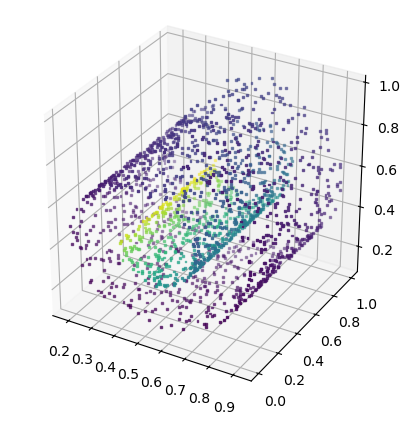

In [8]:
# visualizing a dataset
    
X, Y_true, Y_noise = swill_roll_non_embed_f(n_data = 2000, f = swill_roll_f4)

x = X[:,0]
y = X[:,1]
z_1 = X[:,2]
colo = Y_true

# creating figures
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
# setting color bar
color_map = pylab.cm.ScalarMappable()
color_map.set_array(colo)  
img = ax.scatter(x, y, z_1, marker='s',
                 s=2, c= colo)
# plt.colorbar(color_map)
ax.set_box_aspect([1,1,1])
# displaying plot
plt.show()

# plot (u,v) color by y

In [10]:
#Noise level
sigmasq_0 = 0.01

#MCMC params
mcmc_time = 3000
burn_in = 1000


In [12]:
#grid_pos_param of the marginal posterior of t
n_grid = 400
left_end = 0.0001 
right_end = 0.5
ls_grid_epsilon = np.linspace(left_end, right_end, n_grid)
grid_pos_tolerance = 10**(-10)


In [15]:
#Function to run EB GP for given train size & replicas 
def knn_mcmc_swissroll(train_size, replicas, n_data,sigmasq_0,
                      n_grid, left_end,right_end,grid_pos_tolerance,
                      a_0,b_0, gamma1, gamma2, 
                      burn_in, mcmc_time):
    
    test_size = n_data - train_size
    k_data = 2 if train_size < 200 else math.ceil(np.log(train_size)**(2) * gamma2) #k of knn
    k_size = train_size if train_size < 200 else math.ceil(np.log(train_size)**3)  #|S|
    ls_grid_epsilon = np.linspace(left_end, right_end, n_grid)
    ls_w_pos_knn =  np.zeros(replicas)
    ls_w_pos_knn_test = np.zeros(replicas)
    log_grid_likelihoods = np.zeros(n_grid)
    log_grid_prior = np.zeros(n_grid)
    log_grid_pos = np.zeros(n_grid)
    Tn2_replicas = np.zeros(replicas)
    Tn_count_total = np.zeros(replicas)
    
    for replica in range(replicas):
        start = time.time()
        X, Y_de, Y = swill_roll_non_embed_f(n_data = n_data, sigma_noise = np.sqrt(sigmasq_0), f= swill_roll_f4)   
        idx = np.arange(n_data)
        np.random.shuffle(idx)
        train_idx, test_idx = idx[:train_size], idx[train_size:]
        X_train, X_test = X[train_idx], X[test_idx]
        Y_de_train, Y_de_test = Y_de[train_idx], Y_de[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx] 
        #Pairwise distance   
        dists_XX = scipy.spatial.distance.cdist(X_train, X_train)
        dists_pX = scipy.spatial.distance.cdist(X_test, X_train)
        dists_XX_sq = dists_XX**2
        dists_pX_sq = dists_pX**2
        # KNN tables    
        k_nn_subtable = np.sort(dists_XX[:k_size, :], axis = 1)
        k_nn_distance_grid = (np.mean(k_nn_subtable[:,k_data]))**2 #Tn^2
        Tn2_replicas[replica] = k_nn_distance_grid
        
        #Compute the proposal step size and start point from the grid posterior
        for i, epsilon in enumerate(ls_grid_epsilon):
            #Compute the kernel for different bandwidths  
            k_XX_de =  np.exp(-0.5 * dists_XX_sq/epsilon)
            k_pX =  np.exp(-0.5 * dists_pX_sq/epsilon)
            k_XX = np.copy(k_XX_de)
            k_XX = k_XX + np.eye(train_size) *sigmasq_0
        
            hat_inverse = np.linalg.solve(k_XX, Y_train)
            log_grid_likelihoods[i] = -0.5 * np.matmul(Y_train, hat_inverse)
            log_grid_likelihoods[i] += -0.5 * np.linalg.slogdet(k_XX)[1]
    
            R_hat= (k_XX_de.sum(1)-1)/(k_XX_de.shape[1]-1)
            v_hat_grid = np.mean(R_hat)
            log_grid_prior[i] = - a_0 * np.log(epsilon) - b_0/v_hat_grid #our EB prior
    
            if epsilon > k_nn_distance_grid * gamma1:
                log_grid_pos[i] = log_grid_likelihoods[i] + log_grid_prior[i]
            else: 
                log_grid_pos[i] = -np.infty #p(t)=0 if t< Tn*gamma1
                
        weight_pos = np.exp(log_grid_pos - np.max(log_grid_pos))
        weight_pos = weight_pos/np.sum(weight_pos)
        pos_grid_maxp = ls_grid_epsilon[np.argmax(weight_pos)]
    
        ls_grid_select=ls_grid_epsilon[weight_pos>grid_pos_tolerance]
        sigma_proposal_knn =(max(ls_grid_select) - min(ls_grid_select))/25
    
        ls_epsilon = np.zeros(mcmc_time)
        log_pos_knn = np.zeros(mcmc_time)

        #set initial values for mcmc
        ls_epsilon[0] = pos_grid_maxp
        epsilon = ls_epsilon[0]
        k_XX_de =  np.exp(-0.5 * dists_XX_sq/epsilon)
        k_pX =  np.exp(-0.5 * dists_pX_sq/epsilon)
        k_XX = np.copy(k_XX_de)
        k_XX = k_XX + np.eye(train_size) *sigmasq_0
        hat_inverse = np.linalg.solve(k_XX, Y_train)
        log_likelihood = -0.5 * np.matmul(Y_train, hat_inverse)
        log_likelihood += -0.5 * np.linalg.slogdet(k_XX)[1]
        R_hat= (k_XX_de.sum(1)-1)/(k_XX_de.shape[1]-1)
        v_hat = np.mean(R_hat)
        log_pos_knn[0] = log_likelihood - a_0 * np.log(epsilon) - b_0/v_hat

        
        Y_pred_train = np.zeros((mcmc_time,train_size))
        Y_pred_test = np.zeros((mcmc_time,test_size))
        Tn_count = 0
        for i in range(1, mcmc_time):  
            #gaussian proposal with given step size
            epsilon = (np.random.randn(1)*sigma_proposal_knn + ls_epsilon[i-1])[0]
            if (epsilon < gamma1* k_nn_distance_grid) or (epsilon < left_end) or epsilon > right_end:
                ls_epsilon[i] = ls_epsilon[i-1]
                Y_pred_train[i,:] = Y_pred_train[i-1,:]
                Y_pred_test[i,:] = Y_pred_test[i-1,:]
                log_pos_knn[i] = log_pos_knn[i-1]
                if (epsilon < gamma1* k_nn_distance_grid):
                    Tn_count += 1
                continue
                
            k_XX_de =  np.exp(-0.5 * dists_XX_sq/epsilon)
            k_pX =  np.exp(-0.5 * dists_pX_sq/epsilon)
            k_XX = np.copy(k_XX_de)
            k_XX = k_XX + np.eye(train_size) *sigmasq_0
            hat_inverse = np.linalg.solve(k_XX, Y_train)
            log_likelihood = -0.5 * np.matmul(Y_train, hat_inverse)
            log_likelihood += -0.5 * np.linalg.slogdet(k_XX)[1]
            R_hat= (k_XX_de.sum(1)-1)/(k_XX_de.shape[1]-1)
            v_hat = np.mean(R_hat)
            log_pos_knn_can = log_likelihood - a_0 * np.log(epsilon) - b_0/v_hat
            log_pos_raio = min(0., log_pos_knn_can - log_pos_knn[i-1])
            accept_flag = np.log(np.random.uniform(0,1)) <= log_pos_raio
            if accept_flag:
                ls_epsilon[i] = epsilon
                Y_pred_train[i,:] = np.matmul(k_XX_de, hat_inverse)
                Y_pred_test[i,:] = np.matmul(k_pX, hat_inverse)
                log_pos_knn[i] = log_pos_knn_can
            else:
                ls_epsilon[i] = ls_epsilon[i-1]
                Y_pred_train[i,:] = Y_pred_train[i-1,:]
                Y_pred_test[i,:] = Y_pred_test[i-1,:]
                log_pos_knn[i] = log_pos_knn[i-1]
        Tn_count_total[replica] = Tn_count
        
        err_in = np.sqrt(np.mean((Y_de_train - np.mean(Y_pred_train[burn_in:], axis = 0))**2))
        err_te = np.sqrt(np.mean((Y_de_test - np.mean(Y_pred_test[burn_in:], axis = 0))**2))
        ls_w_pos_knn[replica] = err_in
        ls_w_pos_knn_test[replica] = err_te
        print(f"{replica} replica time: {(time.time() - start):.2f}, Tn_count {Tn_count}")
        print(f"proposal: {sigma_proposal_knn:.2e}, start_point: {pos_grid_maxp:.2f}")
    
    return ls_w_pos_knn, ls_w_pos_knn_test, Tn_count_total, log_grid_pos,ls_epsilon

In [17]:
#Function to run Rescaled gamma GP for given train size & replicas 
def rescaled_mcmc_swissroll(train_size, replicas, n_data, sigmasq_0,
                           n_grid,left_end,right_end, grid_pos_tolerance,
                           a_0, b_0, d, 
                           burn_in, mcmc_time):
    
    test_size = n_data - train_size
    ls_grid_epsilon = np.linspace(left_end, right_end, n_grid)
    ls_w_pos =  np.zeros(replicas)
    ls_w_pos_test = np.zeros(replicas)
    log_grid_likelihoods = np.zeros(n_grid)
    log_grid_prior = np.zeros(n_grid)
    log_grid_pos = np.zeros(n_grid)
    log_grid_pos_knn = np.zeros(n_grid)
    
    for replica in range(replicas):
        start = time.time()
        X, Y_de, Y = swill_roll_non_embed_f(n_data = n_data, sigma_noise = np.sqrt(sigmasq_0), f= swill_roll_f4)   
        idx = np.arange(n_data)
        np.random.shuffle(idx)
        train_idx, test_idx = idx[:train_size], idx[train_size:]
        X_train, X_test = X[train_idx], X[test_idx]
        Y_de_train, Y_de_test = Y_de[train_idx], Y_de[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx] 
        #Pairwise distance   
        dists_XX = scipy.spatial.distance.cdist(X_train, X_train)
        dists_pX = scipy.spatial.distance.cdist(X_test, X_train)
        dists_XX_sq = dists_XX**2
        dists_pX_sq = dists_pX**2
    
    
        #Compute the proposal step size and start point from the grid posterior
        for i, epsilon in enumerate(ls_grid_epsilon):
            k_XX_de =  np.exp(-0.5 * dists_XX_sq/epsilon)
            k_pX =  np.exp(-0.5 * dists_pX_sq/epsilon)
            k_XX = np.copy(k_XX_de)
            k_XX = k_XX + np.eye(train_size) *sigmasq_0
            
            hat_inverse = np.linalg.solve(k_XX, Y_train)
            log_grid_likelihoods[i] = -0.5 * np.matmul(Y_train, hat_inverse)
            log_grid_likelihoods[i] += -0.5 * np.linalg.slogdet(k_XX)[1]
            
            #log prior for varying d: (-a_0*d/2 -1)*log(epsilon) - b_0/epsilon**{d/2}
            log_grid_prior[i] = (-a_0*d/2 - 1)*np.log(epsilon)  - b_0/epsilon **(d/2)
            
            log_grid_pos[i] = log_grid_likelihoods[i] + log_grid_prior[i]
    
        weight_pos = np.exp(log_grid_pos - np.max(log_grid_pos))
        weight_pos = weight_pos/np.sum(weight_pos)
        pos_grid_maxp = ls_grid_epsilon[np.argmax(weight_pos)]
        
        ls_grid_select=ls_grid_epsilon[weight_pos>grid_pos_tolerance]
        sigma_proposal =(max(ls_grid_select) - min(ls_grid_select))/25
          
        ls_epsilon = np.zeros(mcmc_time)
        log_pos = np.zeros(mcmc_time)
        
        #set initial values for mcmc
        ls_epsilon[0] = pos_grid_maxp
        epsilon = ls_epsilon[0]
        k_XX_de =  np.exp(-0.5 * dists_XX_sq/epsilon)
        k_pX =  np.exp(-0.5 * dists_pX_sq/epsilon)
        k_XX = np.copy(k_XX_de)
        k_XX = k_XX + np.eye(train_size) *sigmasq_0
        hat_inverse = np.linalg.solve(k_XX, Y_train)
        log_likelihood = -0.5 * np.matmul(Y_train, hat_inverse)
        log_likelihood += -0.5 * np.linalg.slogdet(k_XX)[1]
        log_pos[0] = log_likelihood + (-a_0*d/2 - 1)*np.log(epsilon)  - b_0/epsilon **(d/2)
        
        
        Y_pred_train = np.zeros((mcmc_time,train_size))
        Y_pred_test = np.zeros((mcmc_time,test_size))
        for i in range(1, mcmc_time):
            #Gaussian proposal with given step size
            epsilon = (np.random.randn(1)*sigma_proposal + ls_epsilon[i-1])[0]
            if (epsilon < left_end) or epsilon > right_end:
                ls_epsilon[i] = ls_epsilon[i-1]
                Y_pred_train[i,:] = Y_pred_train[i-1,:]
                Y_pred_test[i,:] = Y_pred_test[i-1,:]
                log_pos[i] = log_pos[i-1]
                continue
            k_XX_de =  np.exp(-0.5 * dists_XX_sq/epsilon)
            k_pX =  np.exp(-0.5 * dists_pX_sq/epsilon)
            k_XX = np.copy(k_XX_de)
            k_XX = k_XX + np.eye(train_size) *sigmasq_0
            hat_inverse = np.linalg.solve(k_XX, Y_train)
            log_likelihood = -0.5 * np.matmul(Y_train, hat_inverse)
            log_likelihood += -0.5 * np.linalg.slogdet(k_XX)[1]
            log_pos_can = log_likelihood + (-a_0*d/2 - 1)*np.log(epsilon)  - b_0/epsilon **(d/2)
            log_pos_raio = min(0., log_pos_can - log_pos[i-1])
            accept_flag = np.log(np.random.uniform(0,1)) <= log_pos_raio
            if accept_flag:
                ls_epsilon[i] = epsilon
                Y_pred_train[i,:] = np.matmul(k_XX_de, hat_inverse)
                Y_pred_test[i,:] = np.matmul(k_pX, hat_inverse)
                log_pos[i] = log_pos_can
            else:
                ls_epsilon[i] = ls_epsilon[i-1]
                Y_pred_train[i,:] = Y_pred_train[i-1,:]
                Y_pred_test[i,:] = Y_pred_test[i-1,:]
                log_pos[i] = log_pos[i-1]
        err_in = np.sqrt(np.mean((Y_de_train - np.mean(Y_pred_train[burn_in:], axis = 0))**2))
        err_te = np.sqrt(np.mean((Y_de_test - np.mean(Y_pred_test[burn_in:], axis = 0))**2))
        ls_w_pos[replica] = err_in
        ls_w_pos_test[replica] = err_te
        print(f"{replica} replica time: {(time.time() - start):.2f}")
        print(f"proposal: {(sigma_proposal):.2e}, start_point: {pos_grid_maxp:.2f}")
        
    return ls_w_pos,ls_w_pos_test, log_grid_pos,ls_epsilon

In [20]:
#Function to run Kernel Ridge with cross validation for given train size & replicas 
def kernel_ridge_swissroll(train_size, replicas,val_percent,n_data,sigmasq_0,
                           n_grid, left_end,right_end):
    test_size = n_data - train_size
    ls_insample = np.zeros((replicas,n_grid))
    ls_outsample = np.zeros((replicas,n_grid))
    ls_grid_epsilon = np.linspace(left_end, right_end, n_grid)
    ls_val = np.zeros((replicas,n_grid))
    for replica in range(replicas):
        start = time.time()
        X, Y_de, Y = swill_roll_non_embed_f(n_data = n_data, sigma_noise = np.sqrt(sigmasq_0), f= swill_roll_f4)   
        idx = np.arange(n_data)
        np.random.shuffle(idx)
        train_idx, test_idx = idx[:train_size], idx[train_size:]
        X_train, X_test = X[train_idx], X[test_idx]
        Y_de_train, Y_de_test = Y_de[train_idx], Y_de[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx] 
        #Pairwise distance   
        dists_XX = scipy.spatial.distance.cdist(X_train, X_train)
        dists_pX = scipy.spatial.distance.cdist(X_test, X_train)
        dists_XX_sq = dists_XX**2
        dists_pX_sq = dists_pX**2
        val_size = int(np.ceil(train_size *val_percent))
       
        #train-validation split
        dists_XX_sq_kr,dists_vX_sq_kr, dists_pX_sq_kr = dists_XX_sq[val_size:,val_size:],dists_XX_sq[:val_size,val_size:],dists_pX_sq[:,val_size:]
        Y_de_train_kr,Y_de_val_kr = Y_de_train[val_size:],Y_de_train[:val_size]
        Y_train_kr,Y_val_kr = Y_train[val_size:], Y_train[:val_size]
        
        
        #kernel ridge with cross validation, on a given grid of t
        Y_pred_train = np.zeros((n_grid,train_size-val_size))
        Y_pred_test = np.zeros((n_grid,test_size))
        Y_pred_val = np.zeros((n_grid,val_size))
        for i, epsilon in enumerate(ls_grid_epsilon):
            k_XX_de =  np.exp(-0.5 * dists_XX_sq_kr/epsilon)
            k_pX =  np.exp(-0.5 * dists_pX_sq_kr/epsilon)
            k_XX = np.copy(k_XX_de)
            k_XX = k_XX + np.eye(train_size-val_size) *sigmasq_0
            k_vX = np.exp(-0.5 * dists_vX_sq_kr/epsilon)
            
            hat_inverse = np.linalg.solve(k_XX, Y_train_kr)
            Y_pred_train[i,:] = np.matmul(k_XX_de, hat_inverse)
            Y_pred_test[i,:] = np.matmul(k_pX, hat_inverse)
            Y_pred_val[i,:] = np.matmul(k_vX, hat_inverse)
            ls_insample[replica, i] = np.mean(np.power(Y_de_train_kr - Y_pred_train[i,:],2))
            ls_outsample[replica, i] = np.mean(np.power(Y_de_test - Y_pred_test[i,:],2))
            ls_val[replica, i] = np.mean(np.power(Y_de_val_kr - Y_pred_val[i,:],2))
    
        print(f"{replica} replica time: {(time.time() - start):.2f}")
        
    ls_kernel_ridge =np.sqrt(np.array([ls_insample[enum, item] for enum, item in enumerate(np.argsort(ls_val)[:,0])]))
    ls_kernel_ridge_test = np.sqrt(np.array([ls_outsample[enum, item] for enum, item in enumerate(np.argsort(ls_val)[:,0])]))
    return ls_kernel_ridge,ls_kernel_ridge_test

In [23]:
#Driver of knn
#Parameters for the kNN prior, as in paper
gamma1 = 0.25
gamma2 = 0.25
a_0 = 1
b_0 = 1

replicas = 5 # to recover fig 2 in paper, change to 100
train_size_ls = [50,100,200] #to recover fig 2 in paper, change to [50,100,200,400,800,1600]
test_size = 2000

w_pos_knn_means = []
w_pos_knn_std = []
w_pos_knn_test_means = []
w_pos_knn_test_std = []
dict_Tn_count = {}
dict_log_grid_pos_knn = {}
dict_ls_epsilon_knn = {}

for train_size in train_size_ls:
    n_data = train_size + test_size
    ls_w_pos_knn,ls_w_pos_knn_test, dict_Tn_count[train_size], dict_log_grid_pos_knn[train_size], dict_ls_epsilon_knn[train_size] \
     = knn_mcmc_swissroll(train_size, replicas, n_data,sigmasq_0,
                      n_grid, left_end,right_end,grid_pos_tolerance,
                      a_0,b_0, gamma1, gamma2, 
                      burn_in, mcmc_time)
    w_pos_knn_means.append(np.mean(ls_w_pos_knn))
    w_pos_knn_std.append(np.std(ls_w_pos_knn))
    w_pos_knn_test_means.append(np.mean(ls_w_pos_knn_test))
    w_pos_knn_test_std.append(np.std(ls_w_pos_knn_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_w_pos_knn)}, OS error {np.mean(ls_w_pos_knn_test)}")

0 replica time: 2.42, Tn_count 0
proposal: 1.00e-03, start_point: 0.03
1 replica time: 2.51, Tn_count 0
proposal: 9.52e-04, start_point: 0.03
2 replica time: 3.25, Tn_count 0
proposal: 9.52e-04, start_point: 0.04
3 replica time: 2.96, Tn_count 0
proposal: 7.52e-04, start_point: 0.03
4 replica time: 2.40, Tn_count 0
proposal: 8.52e-04, start_point: 0.03
train_size 50, IS error 0.0952389880900492, OS error 0.7267926724339423
0 replica time: 5.55, Tn_count 0
proposal: 8.02e-04, start_point: 0.03
1 replica time: 5.74, Tn_count 0
proposal: 7.02e-04, start_point: 0.03
2 replica time: 7.04, Tn_count 0
proposal: 7.52e-04, start_point: 0.03
3 replica time: 5.74, Tn_count 0
proposal: 8.02e-04, start_point: 0.03
4 replica time: 6.69, Tn_count 0
proposal: 7.52e-04, start_point: 0.03
train_size 100, IS error 0.08998677973176307, OS error 0.330315962768032
0 replica time: 14.16, Tn_count 0
proposal: 7.02e-04, start_point: 0.03
1 replica time: 14.86, Tn_count 0
proposal: 6.51e-04, start_point: 0.03
2

In [ ]:
#Driver of rescaled gamma Gp

#rescaled gamma param
d = 2
a_0 = 1
b_0 = 1 

w_pos_means = []
w_pos_std = []
w_pos_test_means = []
w_pos_test_std = []
dict_log_grid_pos = {}
dict_ls_epsilon = {}

for train_size in train_size_ls:
    n_data = train_size + test_size
    ls_w_pos,ls_w_pos_test,dict_log_grid_pos[train_size], dict_ls_epsilon[train_size] = \
    rescaled_mcmc_swissroll(train_size, replicas, n_data, sigmasq_0,
                           n_grid,left_end,right_end, grid_pos_tolerance,
                           a_0, b_0, d, 
                           burn_in, mcmc_time)
    w_pos_means.append(np.mean(ls_w_pos))
    w_pos_std.append(np.std(ls_w_pos))
    w_pos_test_means.append(np.mean(ls_w_pos_test))
    w_pos_test_std.append(np.std(ls_w_pos_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_w_pos)}, OS error {np.mean(ls_w_pos_test)}")

0 replica time: 2.48
proposal: 1.15e-03, start_point: 0.04
1 replica time: 2.51
proposal: 9.02e-04, start_point: 0.03
2 replica time: 2.29
proposal: 1.10e-03, start_point: 0.04
3 replica time: 2.67
proposal: 8.52e-04, start_point: 0.03
4 replica time: 2.34
proposal: 1.00e-03, start_point: 0.04
train_size 50, IS error 0.1016809536223902, OS error 0.8683340213108572
0 replica time: 5.82
proposal: 8.02e-04, start_point: 0.03
1 replica time: 7.06
proposal: 8.02e-04, start_point: 0.04
2 replica time: 6.23
proposal: 8.02e-04, start_point: 0.03
3 replica time: 6.00
proposal: 8.52e-04, start_point: 0.04
4 replica time: 7.36
proposal: 8.02e-04, start_point: 0.04
train_size 100, IS error 0.09542877276468105, OS error 0.4432277289662846


In [ ]:
#Driver of kernel ridge cv

val_percent = 0.1 # validation set percentage 
cv_means = []
cv_std = []
cv_test_means = []
cv_test_std = []
for train_size in train_size_ls:
    n_data = train_size + test_size
    ls_kernel_ridge,ls_kernel_ridge_test = kernel_ridge_swissroll(train_size, replicas,val_percent,n_data,sigmasq_0,
                           n_grid, left_end,right_end)
    cv_means.append(np.mean(ls_kernel_ridge))
    cv_std.append(np.std(ls_kernel_ridge))
    cv_test_means.append(np.mean(ls_kernel_ridge_test))
    cv_test_std.append(np.std(ls_kernel_ridge_test))
    print(f"train_size {train_size}, IS error {np.mean(ls_kernel_ridge)}, OS error {np.mean(ls_kernel_ridge_test)}")

In [ ]:
data_number_all = [50,100,200]# Change to [50,100,200,400,800,1600] for reproduce figure 2 in paper

In [ ]:
#plot for figure
#In-sample error 
plt.figure(figsize=(5,4))
plt.errorbar(data_number_all, w_pos_knn_means, w_pos_knn_std, linestyle='-', marker='*',label = "knn gp",capsize=5, capthick=2)
plt.errorbar(data_number_all, w_pos_means, w_pos_std, linestyle='-', marker='*',label = "rescaled gp d=2",capsize=5, capthick=2)
plt.errorbar(data_number_all, cv_means, cv_std, linestyle='-', marker='*',label = "kernel_ridge_cv" ,capsize=5, capthick=2)
plt.xlabel('number of training data', fontsize = 15)
plt.grid()
plt.title(r'$||\hat{f}-f^*||_{n}$ on training data', fontsize = 18)
plt.xscale('log')
plt.ylim([0,0.5])
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.legend(fontsize=13)
plt.show()

#Out-of-sample error 
plt.figure(figsize=(5,4))
plt.errorbar(data_number_all, w_pos_knn_test_means, w_pos_knn_test_std, linestyle='-', marker='*',label = "knn gp",capsize=5, capthick=2)
plt.errorbar(data_number_all, w_pos_test_means, w_pos_test_std, linestyle='-', marker='*',label = "rescaled gp d=2",capsize=5, capthick=2)
plt.errorbar(data_number_all, cv_test_means, cv_test_std, linestyle='-', marker='*',label = "kernel_ridge_cv" ,capsize=5, capthick=2)
plt.xlabel('number of training data', fontsize = 15)
plt.grid()
plt.title(r'$||\hat{f}-f^*||_{2}$ on testing data', fontsize = 18)
plt.xscale('log')
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.legend(fontsize=13)
plt.show()